# 4 — Modelagem e Validação Cruzada Aninhada

**Pré-requisito:** `data/processed/dataset.csv` gerado pelo notebook 2.

**Saídas:** `data/processed/results.pkl`, `figures/confusion_matrices.png`, `figures/feature_importance.png`

In [1]:
import pickle
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3

np.random.seed(RANDOM_STATE)

ROOT_DIR      = Path('.')
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
FIGURES_DIR   = ROOT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = PROCESSED_DIR / 'dataset.csv'
RESULTS_PATH = PROCESSED_DIR / 'results.pkl'

FEATURE_COLS = [
    'n_vertices', 'n_edges', 'density',
    'min_degree', 'max_degree', 'mean_degree', 'std_degree',
    'avg_clustering', 'diameter', 'is_disconnected',
    'avg_betweenness', 'largest_clique', 'n_components',
]

FEATURE_LABELS = {
    'n_vertices'     : 'Nº Vértices',
    'n_edges'        : 'Nº Arestas',
    'density'        : 'Densidade',
    'min_degree'     : 'Grau Mínimo',
    'max_degree'     : 'Grau Máximo',
    'mean_degree'    : 'Grau Médio',
    'std_degree'     : 'Desvio Grau',
    'avg_clustering' : 'Coef. Agrupamento',
    'diameter'       : 'Diâmetro',
    'is_disconnected': 'Desconexo',
    'avg_betweenness': 'Betweenness Médio',
    'largest_clique' : 'Maior Clique',
    'n_components'   : 'Nº Componentes',
}

df = pd.read_csv(DATASET_PATH)
X  = df[FEATURE_COLS].values.astype(float)
y  = df['chi'].values.astype(int)

print(f'Dataset: {X.shape[0]} instâncias, {X.shape[1]} atributos')
print(f'Classes: {sorted(np.unique(y))}')

Dataset: 440 instâncias, 13 atributos
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(19), np.int64(20), np.int64(21), np.int64(23)]


## Modelos e Grades de Hiperparâmetros

In [2]:
MODELS = {
    'Árvore de Decisão': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            'max_depth'        : [5, 10, 20, None],
            'min_samples_split': [2, 5, 10],
            'criterion'        : ['gini', 'entropy'],
        },
    ),
    'Floresta Aleatória': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {
            'n_estimators': [50, 100, 200],
            'max_depth'   : [10, 20, None],
            'max_features': ['sqrt', 'log2'],
        },
    ),
    'SVM': (
        SVC(kernel='rbf', random_state=RANDOM_STATE),
        {
            'C'    : [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.001],
        },
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3, 5, 7, 11],
            'weights'    : ['uniform', 'distance'],
            'metric'     : ['euclidean', 'manhattan'],
        },
    ),
    'MLP': (
        MLPClassifier(max_iter=1000, random_state=RANDOM_STATE),
        {
            'hidden_layer_sizes': [(64,), (128,), (64, 32)],
            'learning_rate_init': [0.001, 0.01],
            'alpha'             : [0.0001, 0.001],
        },
    ),
}

for name, (_, grid) in MODELS.items():
    n = 1
    for v in grid.values():
        n *= len(v)
    print(f'  {name:<22} {n} combinações × {N_INNER_FOLDS} = {n*N_INNER_FOLDS} fits')

  Árvore de Decisão      24 combinações × 3 = 72 fits
  Floresta Aleatória     18 combinações × 3 = 54 fits
  SVM                    16 combinações × 3 = 48 fits
  KNN                    16 combinações × 3 = 48 fits
  MLP                    12 combinações × 3 = 36 fits


## Validação Cruzada Aninhada

In [3]:
def run_nested_cv(X, y, models, n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS):
    """
    Loop externo : Stratified K-Fold  (avaliação)
    Por fold     : StandardScaler → SMOTE → Grid Search (loop interno)
    Loop interno : Stratified K-Fold  (seleção de hiperparâmetros)
    """
    outer_cv   = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=RANDOM_STATE)
    all_labels = sorted(np.unique(y))

    results = {
        name: {k: [] for k in ['accuracy', 'precision', 'recall', 'f1', 'conf_matrix', 'best_params']}
        for name in models
    }

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), 1):
        print(f'\n{"─"*60}')
        print(f'Fold {fold}/{n_outer}')

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        min_count   = int(np.bincount(y_tr).min())
        k_neighbors = max(1, min(5, min_count - 1))
        try:
            smote        = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
            X_res, y_res = smote.fit_resample(X_tr_sc, y_tr)
            print(f'  SMOTE: {len(y_tr)} → {len(y_res)} (k={k_neighbors})')
        except Exception as e:
            print(f'  SMOTE falhou ({e}). Usando treino original.')
            X_res, y_res = X_tr_sc, y_tr

        for name, (model, param_grid) in models.items():
            t0       = time.time()
            inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=RANDOM_STATE)
            gs = GridSearchCV(
                estimator=model, param_grid=param_grid, cv=inner_cv,
                scoring='f1_weighted', n_jobs=-1, refit=True, error_score=0.0,
            )
            gs.fit(X_res, y_res)
            y_pred = gs.predict(X_te_sc)

            acc = accuracy_score(y_te, y_pred)
            pre = precision_score(y_te, y_pred, average='weighted', zero_division=0)
            rec = recall_score   (y_te, y_pred, average='weighted', zero_division=0)
            f1  = f1_score       (y_te, y_pred, average='weighted', zero_division=0)
            cm  = confusion_matrix(y_te, y_pred, labels=all_labels)

            results[name]['accuracy'].append(acc)
            results[name]['precision'].append(pre)
            results[name]['recall'].append(rec)
            results[name]['f1'].append(f1)
            results[name]['conf_matrix'].append(cm)
            results[name]['best_params'].append(gs.best_params_)

            print(f'  {name:<22} acc={acc:.3f}  f1={f1:.3f}  ({time.time()-t0:.1f}s)')

    return results, all_labels

In [4]:
if not RESULTS_PATH.exists():
    print('Iniciando validação cruzada aninhada...')
    t0 = time.time()
    results, all_labels = run_nested_cv(X, y, MODELS)
    with open(RESULTS_PATH, 'wb') as f:
        pickle.dump({'results': results, 'all_labels': all_labels}, f)
    print(f'\nResultados salvos em {RESULTS_PATH}  ({time.time()-t0:.1f}s)')
else:
    print(f'Carregando: {RESULTS_PATH}')
    with open(RESULTS_PATH, 'rb') as saved_f:
        saved      = pickle.load(saved_f)
    results    = saved['results']
    all_labels = saved['all_labels']
    print('OK.')

Carregando: data\processed\results.pkl
OK.


## Tabela de Desempenho

In [5]:
rows = []
for name, m in results.items():
    def fmt(key):
        return f'{np.mean(m[key]):.3f} \u00b1 {np.std(m[key]):.3f}'
    rows.append({
        'Modelo'   : name,
        'Acurácia' : fmt('accuracy'),
        'Precisão' : fmt('precision'),
        'Revocação': fmt('recall'),
        'F1'       : fmt('f1'),
    })

results_df = pd.DataFrame(rows).set_index('Modelo')
display(results_df)

best = max(results, key=lambda n: np.mean(results[n]['accuracy']))
print(f'\nMelhor modelo (acurácia): {best} ({np.mean(results[best]["accuracy"]):.3f})')

,Acurácia,Precisão,Revocação,F1
Modelo,,,,
Árvore de Decisão,0.830 ± 0.032,0.827 ± 0.028,0.830 ± 0.032,0.822 ± 0.030
Floresta Aleatória,0.814 ± 0.023,0.816 ± 0.022,0.814 ± 0.023,0.809 ± 0.022
SVM,0.848 ± 0.030,0.837 ± 0.028,0.848 ± 0.030,0.838 ± 0.030
KNN,0.780 ± 0.012,0.777 ± 0.009,0.780 ± 0.012,0.770 ± 0.008
MLP,0.832 ± 0.022,0.828 ± 0.013,0.832 ± 0.022,0.824 ± 0.015



Melhor modelo (acurácia): SVM (0.848)


## Matrizes de Confusão

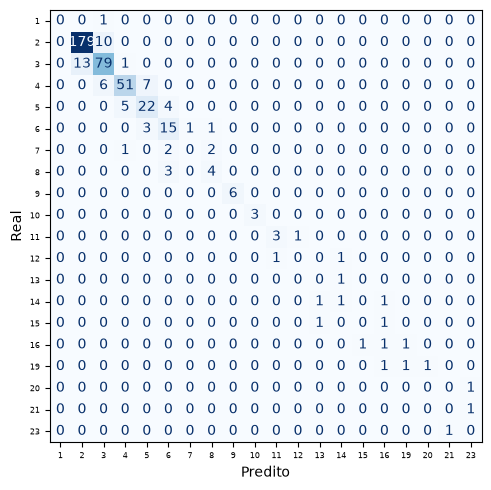

Salvo: figures\confusion_matrix_ad.png


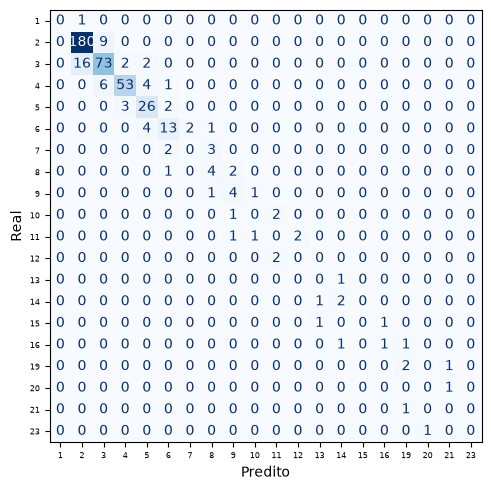

Salvo: figures\confusion_matrix_fa.png


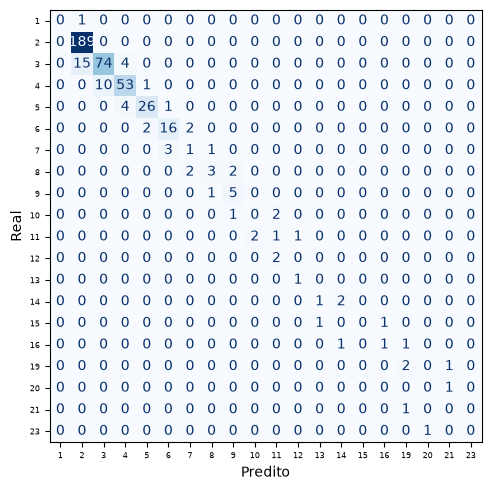

Salvo: figures\confusion_matrix_svm.png


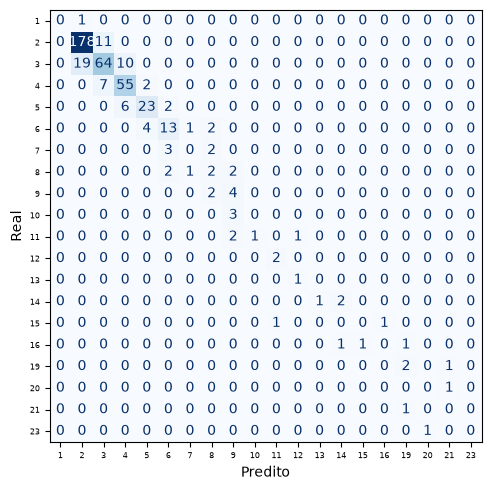

Salvo: figures\confusion_matrix_knn.png


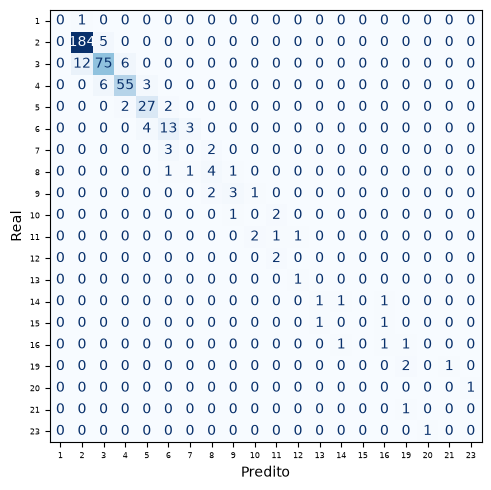

Salvo: figures\confusion_matrix_mlp.png


In [6]:
model_abbrev = {
    'Árvore de Decisão' : 'ad',
    'Floresta Aleatória': 'fa',
    'SVM'               : 'svm',
    'KNN'               : 'knn',
    'MLP'               : 'mlp',
}

for name, m in results.items():
    cm_total = np.sum(m['conf_matrix'], axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_total, display_labels=all_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.tick_params(axis='both', labelsize=6)
    plt.tight_layout()
    fname = FIGURES_DIR / f'confusion_matrix_{model_abbrev[name]}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {fname}')

## Importância de Atributos — Floresta Aleatória

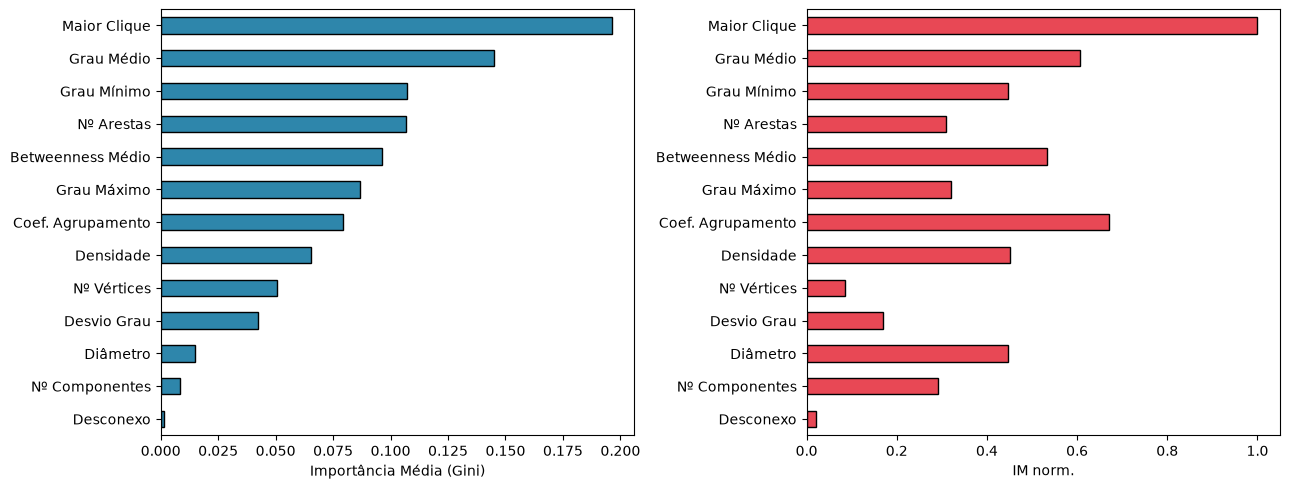

Top-5 RF:
  Maior Clique              0.1962
  Grau Médio                0.1452
  Grau Mínimo               0.1071
  Nº Arestas                0.1066
  Betweenness Médio         0.0963


In [7]:
mi_vals = mutual_info_classif(X, y, random_state=RANDOM_STATE)

scaler_full = StandardScaler()
X_sc_full   = scaler_full.fit_transform(X)

rf_final = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)
rf_final.fit(X_sc_full, y)

rf_imp  = pd.Series(rf_final.feature_importances_,
                     index=[FEATURE_LABELS[f] for f in FEATURE_COLS])
mi_norm = pd.Series(mi_vals / mi_vals.max(),
                     index=[FEATURE_LABELS[f] for f in FEATURE_COLS])

order_idx = rf_imp.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_imp.loc[order_idx].plot(kind='barh', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_xlabel('Importância Média (Gini)')

mi_norm.loc[order_idx].plot(kind='barh', ax=axes[1], color='#E84855', edgecolor='black')
axes[1].set_xlabel('IM norm.')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top-5 RF:')
for feat, val in rf_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<25} {val:.4f}')